In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

In [2]:
df = pd.read_csv(
    "../data/processed/application_final.csv"
)

In [3]:
X = df.drop(
    columns=["TARGET"]
)

y = df["TARGET"]

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [5]:
# Create one template customer using median/mode values
template_customer = X_train.copy().iloc[[0]]

for col in template_customer.columns:

    if template_customer[col].dtype == "object":
        template_customer[col] = X_train[col].mode()[0]
    else:
        template_customer[col] = X_train[col].median()

template_customer.to_csv(
    "../models/template_customer.csv",
    index=False
)

In [6]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [7]:
categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude="object"
).columns.tolist()

In [8]:
numeric_transformer = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )

])

In [9]:
categorical_transformer = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )

])

In [10]:
preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_transformer,
        numerical_cols
    ),

    (
        "categorical",
        categorical_transformer,
        categorical_cols
    )

])

In [11]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

In [12]:
from sklearn.base import clone

def evaluate_model(model, model_name):
    
    # Create fresh pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clone(model))
    ])

    # Cross Validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print("=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    print(f"Cross Validation ROC-AUC Scores : {cv_scores}")
    print(f"Mean ROC-AUC                  : {cv_scores.mean():.4f}")

    # Train model
    pipeline.fit(X_train, y_train)

    # Validation Evaluation
    val_prob = pipeline.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_prob)

    print(f"\nValidation ROC-AUC : {val_auc:.4f}")

    # Test Evaluation
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_prob)

    print(f"Test ROC-AUC       : {test_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    return pipeline

In [13]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced"
)
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

In [14]:
log_pipeline = evaluate_model(
    log_model,
    "Logistic Regression"
)
lgb_pipeline = evaluate_model(
    lgb_model,
    "LightGBM"
)
xgb_pipeline = evaluate_model(
    xgb_model,
    "XGBoost"
)
cat_pipeline = evaluate_model(
    cat_model,
    "CatBoost"
)

Logistic Regression
Cross Validation ROC-AUC Scores : [0.77145796 0.75706482 0.77004189 0.76526048 0.77475317]
Mean ROC-AUC                  : 0.7677

Validation ROC-AUC : 0.7698
Test ROC-AUC       : 0.7707

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     42403
           1       0.17      0.69      0.28      3724

    accuracy                           0.71     46127
   macro avg       0.57      0.70      0.55     46127
weighted avg       0.90      0.71      0.77     46127

Confusion Matrix
[[29979 12424]
 [ 1136  2588]]
LightGBM
Cross Validation ROC-AUC Scores : [0.77400111 0.76016273 0.76832144 0.76598153 0.77538193]
Mean ROC-AUC                  : 0.7688


  File "C:\Users\vrund\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vrund\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vrund\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vrund\anaconda3\Lib\subprocess.

[LightGBM] [Info] Number of positive: 17377, number of negative: 197880
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.103321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25121
[LightGBM] [Info] Number of data points in the train set: 215257, number of used features: 298
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

Validation ROC-AUC : 0.7731
Test ROC-AUC       : 0.7799

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     42403
           1       0.21      0.62      0.32      3724

    accuracy                           0.78     46127
   macro avg       0.59      0.71      0.59     46127
weighted avg       0.90      0.78      0.83     46127

Confusion Matrix
[[33859  8544]
 [ 1430  2294]]
XGBoost
Cross Validation ROC-AUC Scores : [0.77

In [15]:
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200
)
cat_pipeline = evaluate_model(
    cat_model,
    "CatBoost"
)

CatBoost
Cross Validation ROC-AUC Scores : [0.78480054 0.77041613 0.78378009 0.77776227 0.78701427]
Mean ROC-AUC                  : 0.7808
0:	total: 54.3ms	remaining: 1m 48s
200:	total: 11.8s	remaining: 1m 45s
400:	total: 23.3s	remaining: 1m 32s
600:	total: 34.5s	remaining: 1m 20s
800:	total: 45.4s	remaining: 1m 8s
1000:	total: 56.5s	remaining: 56.3s
1200:	total: 1m 7s	remaining: 44.8s
1400:	total: 1m 18s	remaining: 33.5s
1600:	total: 1m 29s	remaining: 22.3s
1800:	total: 1m 40s	remaining: 11.1s
1999:	total: 1m 51s	remaining: 0us

Validation ROC-AUC : 0.7814
Test ROC-AUC       : 0.7857

Classification Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.58      0.04      0.08      3724

    accuracy                           0.92     46127
   macro avg       0.75      0.52      0.52     46127
weighted avg       0.89      0.92      0.89     46127

Confusion Matrix
[[42284   119]
 [ 3562   162]]


In [16]:

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"Fold {i+1}")

    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    X_va = X_train.iloc[val_idx]
    y_va = y_train.iloc[val_idx]

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", CatBoostClassifier(
            iterations=2000,
            learning_rate=0.03,
            depth=8,
            random_seed=42,
            verbose=False
        ))
    ])

    pipe.fit(X_tr, y_tr)

    pred = pipe.predict_proba(X_va)[:, 1]

    print(roc_auc_score(y_va, pred))

Fold 1
0.783035744193398
Fold 2
0.7690752921706568
Fold 3
0.7835915088426529
Fold 4
0.7755868464718825
Fold 5
0.7859033307011152


In [17]:
val_prob = cat_pipeline.predict_proba(
    X_val
)[:,1]

In [18]:
thresholds = np.arange(
    0.1,
    0.95,
    0.05
)
results = []
for threshold in thresholds:

    pred = (
        val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred
    )

    recall = recall_score(
        y_val,
        pred
    )

    f1 = f1_score(
        y_val,
        pred
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [19]:
threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.212182,0.593985,0.312672
1,0.15,0.276842,0.423738,0.334890
2,0.20,0.328214,0.292696,0.309439
3,0.25,0.383063,0.208915,0.270374
4,0.30,0.434420,0.153867,0.227246
5,0.35,0.476534,0.106337,0.173875
6,0.40,0.521073,0.073040,0.128121
7,0.45,0.565625,0.048604,0.089515
8,0.50,0.592965,0.031686,0.060158
9,0.55,0.627119,0.019871,0.038522


In [20]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print(best_threshold)

0.15000000000000002


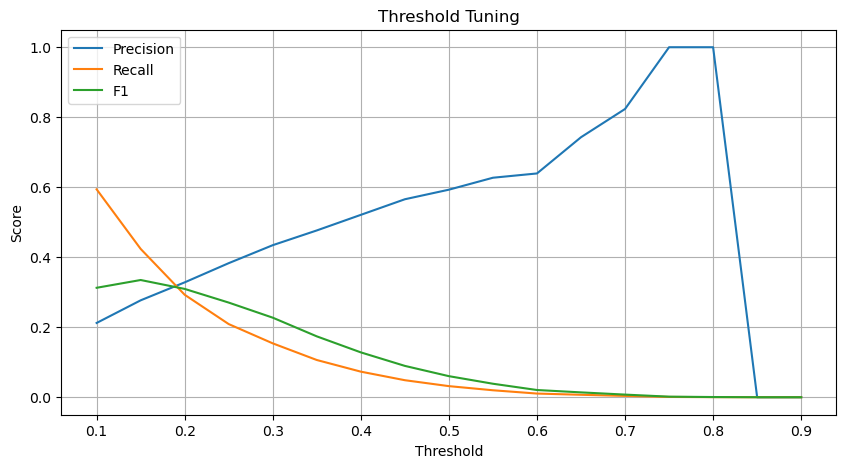

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

plt.grid(True)

plt.show()

In [22]:

test_prob = cat_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("ROC-AUC :", roc_auc_score(y_test, test_prob))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, test_pred))

ROC-AUC : 0.7844667552731016

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     42403
           1       0.28      0.42      0.34      3724

    accuracy                           0.86     46127
   macro avg       0.61      0.66      0.63     46127
weighted avg       0.89      0.86      0.88     46127


Confusion Matrix
[[38276  4127]
 [ 2142  1582]]


In [23]:
comparison = pd.DataFrame({
    "Threshold":[0.50, best_threshold],
    "Precision":[
        0.593,
        threshold_df.loc[
            threshold_df["Threshold"]==best_threshold,
            "Precision"
        ].values[0]
    ],
    "Recall":[
        0.032,
        threshold_df.loc[
            threshold_df["Threshold"]==best_threshold,
            "Recall"
        ].values[0]
    ],
    "F1":[
        0.060,
        threshold_df.loc[
            threshold_df["Threshold"]==best_threshold,
            "F1"
        ].values[0]
    ]
})

comparison

,Threshold,Precision,Recall,F1
0,0.50,0.593000,0.032000,0.06000
1,0.15,0.276842,0.423738,0.33489


In [24]:
# Extract trained model
cat_model = cat_pipeline.named_steps["classifier"]

# Feature names after preprocessing
feature_names = cat_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# CatBoost feature importance
importance = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
29,numeric__EXT_SOURCE_2,8.294591
30,numeric__EXT_SOURCE_3,7.390846
28,numeric__EXT_SOURCE_1,4.663085
7,numeric__DAYS_BIRTH,3.320276
144,numeric__pos_avg_future_installments,2.706611
3,numeric__AMT_CREDIT,2.155519
4,numeric__AMT_ANNUITY,1.985492
5,numeric__AMT_GOODS_PRICE,1.928885
113,numeric__debt_credit_ratio,1.921979
141,numeric__pos_oldest_month,1.875237


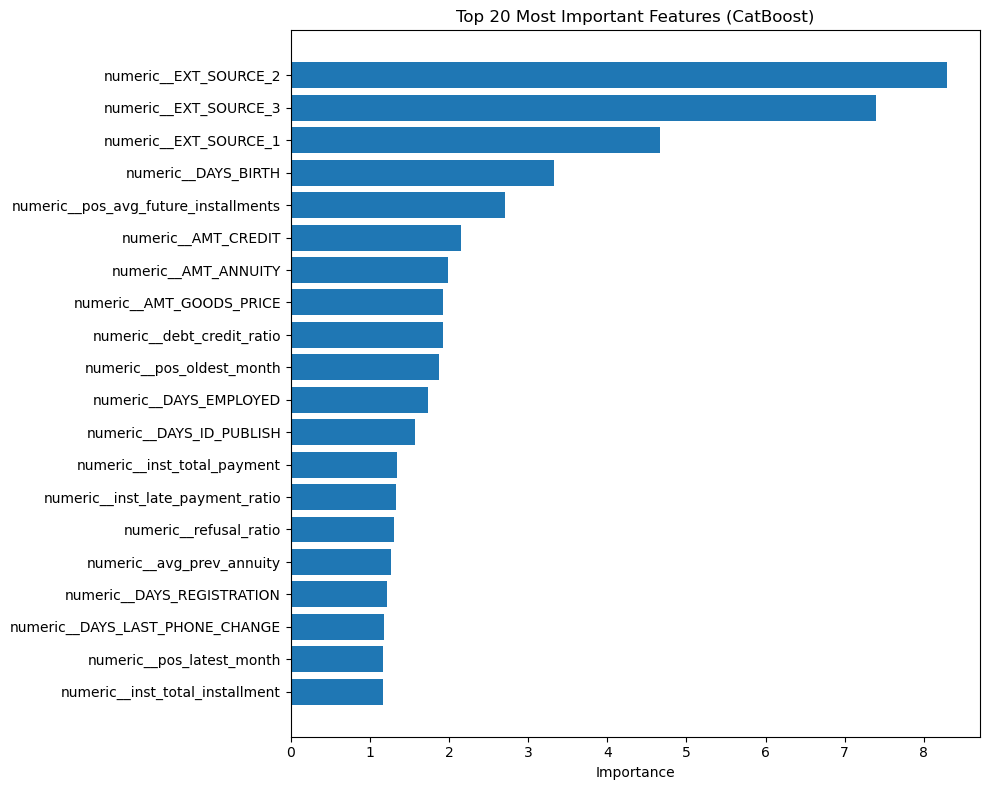

In [25]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Most Important Features (CatBoost)")

plt.tight_layout()
plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [26]:
cat_model = cat_pipeline.named_steps["classifier"]
preprocessor = cat_pipeline.named_steps["preprocessor"]
X_val_processed = preprocessor.transform(X_val)
feature_names = preprocessor.get_feature_names_out()

In [27]:
import shap

explainer = shap.TreeExplainer(cat_model)

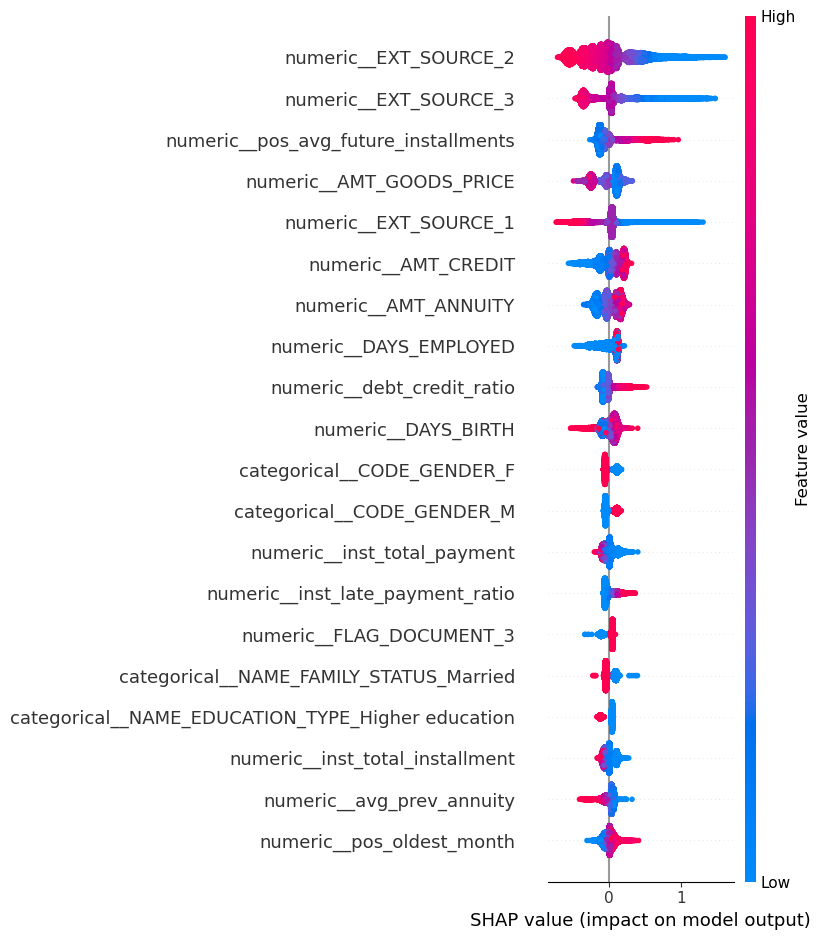

In [28]:
shap_values = explainer.shap_values(X_val_processed)
shap.summary_plot(
    shap_values,
    X_val_processed,
    show=False,
    feature_names=feature_names
)
plt.savefig(
    "../reports/figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

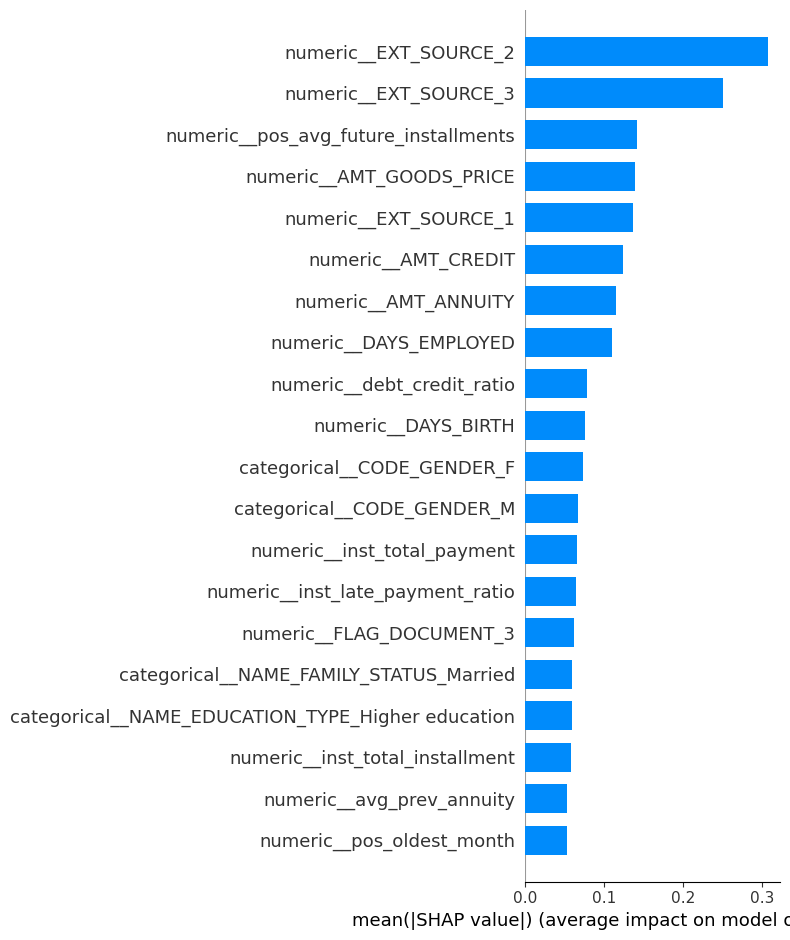

In [29]:
shap.summary_plot(
    shap_values,
    X_val_processed,
    feature_names=feature_names,
    plot_type="bar"
)

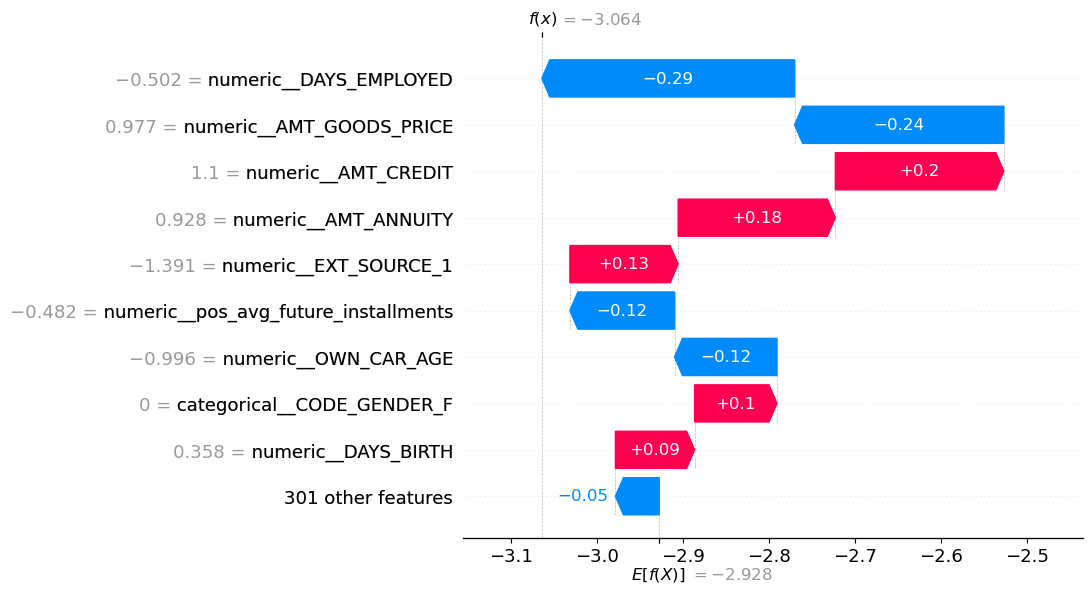

In [30]:
sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_val_processed[sample],
        feature_names=feature_names
    )
)

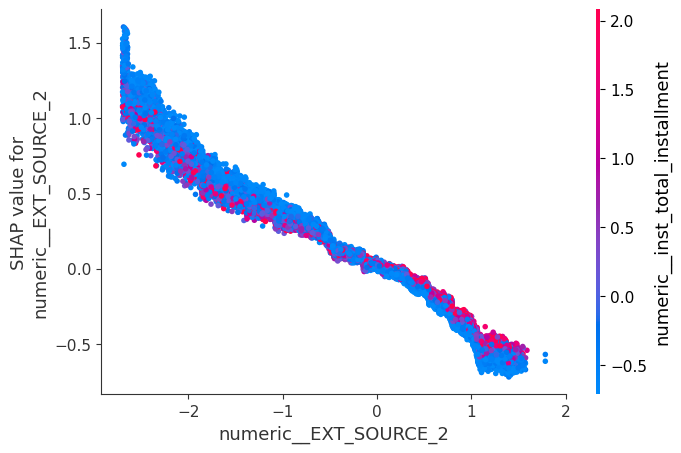

In [31]:
shap.dependence_plot(
    "numeric__EXT_SOURCE_2",
    shap_values,
    X_val_processed,
    feature_names=feature_names
)

In [32]:
# Logistic
log_prob = log_pipeline.predict_proba(X_test)[:, 1]

# LightGBM
lgb_prob = lgb_pipeline.predict_proba(X_test)[:, 1]

# XGBoost
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

# CatBoost
cat_prob = cat_pipeline.predict_proba(X_test)[:, 1]

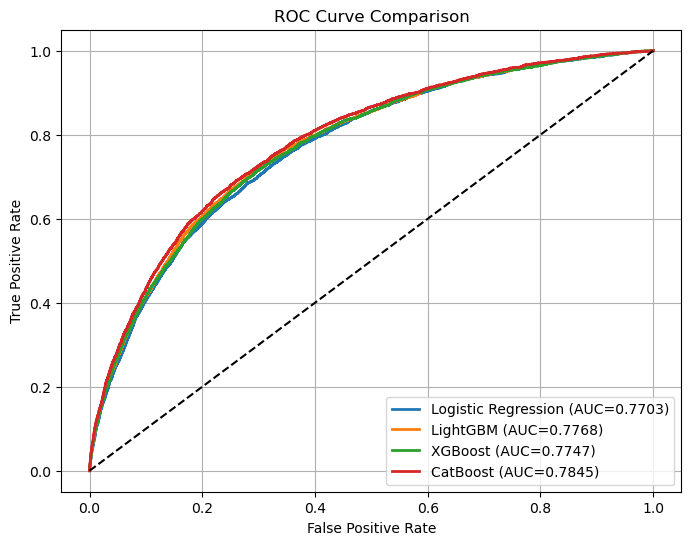

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_prob,
    "LightGBM": lgb_prob,
    "XGBoost": xgb_prob,
    "CatBoost": cat_prob
}

for name, prob in models.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.4f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)
plt.savefig(
    "../reports/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


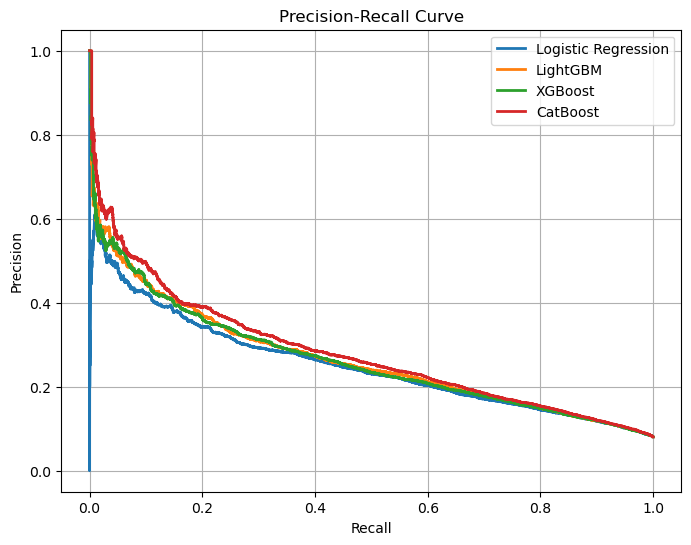

In [34]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, prob in models.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)
plt.savefig(
    "../reports/figures/pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [35]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ],

    "ROC_AUC":[

        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, lgb_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, cat_prob)

    ]

})

comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
3,CatBoost,0.784467
1,LightGBM,0.776806
2,XGBoost,0.774739
0,Logistic Regression,0.770338


In [36]:
import joblib
joblib.dump(
    cat_pipeline,
    "../models/catboost_pipeline.pkl"
)

['../models/catboost_pipeline.pkl']

In [37]:
best_threshold = 0.15

joblib.dump(
    best_threshold,
    "../models/best_threshold.pkl"
)

['../models/best_threshold.pkl']

In [38]:
feature_names = cat_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [39]:
model_metrics = {
    "Model": "CatBoost",
    "Validation ROC-AUC": 0.7814,
    "Test ROC-AUC": 0.7857,
    "Best Threshold": 0.15,
    "Precision": 0.28,
    "Recall": 0.42,
    "F1 Score": 0.34
}

joblib.dump(
    model_metrics,
    "../models/model_metrics.pkl"
)

['../models/model_metrics.pkl']